# Correlation Analysis: Pre-Op Q EQ VAS vs Hip Replacement Pre-Op Q Score (OHS)

This notebook investigates the relationship between:
- **Pre-Op Q EQ VAS**: Patient-reported health state on a Visual Analogue Scale (0–100, where 100 = best imaginable health)
- **Hip Replacement Pre-Op Q Score (OHS)**: Oxford Hip Score — sum of 12 disease-specific questions (range 0–60, where higher = better function)

In [3]:
!pip install pandas numpy matplotlib seaborn scipy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)

print('Libraries loaded.')

  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.1 MB 6.3 MB/s eta 0:00:02
   -------------- ------------------------- 2.9/8.1 MB 8.4 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.1 MB 8.6 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.1 MB 8.9 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 8.4 MB/s  0:00:01
   ---------------------------------------- 0.0/41.3 MB ? eta -:--:--
   - -------------------------------------- 1.6/41.3 MB 10.5 MB/s eta 0:00:04
   --- ------------------------------------ 3.9/41.3 MB 10.2 MB/s eta 0:00:04
   ----- ---------------------------------- 5.5/41.3 MB 9.1 MB/s eta 0:00:04
   ------- -------------------------------- 7.6/41.3 MB 9.0 MB/s eta 0:00:04
   --------- ------------------------------ 9.4/41.3 MB 8.9 MB/s eta 0:00:04
   ----------- ----------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Libraries loaded.


In [4]:
# Load cleaned dataset
df = pd.read_parquet('cleaned_hip_replacement_data.parquet')
print('Dataset loaded.')
print('Shape:', df.shape)

Dataset loaded.
Shape: (111123, 48)


## 1. Extract and Inspect the Two Variables

In [5]:
col_eq_vas = 'Pre-Op Q EQ VAS'
col_ohs    = 'Hip Replacement Pre-Op Q Score'

df_pair = df[[col_eq_vas, col_ohs]].copy()

# Convert to numeric (parquet may store as string for some columns)
df_pair[col_eq_vas] = pd.to_numeric(df_pair[col_eq_vas], errors='coerce')
df_pair[col_ohs]    = pd.to_numeric(df_pair[col_ohs],    errors='coerce')

print('Missing values:')
print(df_pair.isnull().sum())
print(f'\nTotal rows: {len(df_pair)}')

Missing values:
Pre-Op Q EQ VAS                   6372
Hip Replacement Pre-Op Q Score       0
dtype: int64

Total rows: 111123


In [6]:
# Drop rows where either variable is missing
df_clean = df_pair.dropna()
print(f'Rows available for correlation analysis: {len(df_clean):,}')
print(f'Rows dropped (missing in either variable): {len(df_pair) - len(df_clean):,}')

Rows available for correlation analysis: 104,751
Rows dropped (missing in either variable): 6,372


## 2. Descriptive Statistics

In [7]:
print('=== Descriptive Statistics ===')
print(df_clean.describe().T.to_string())

=== Descriptive Statistics ===
                                   count     mean      std  min   25%   50%   75%    max
Pre-Op Q EQ VAS                 104751.0  63.7086  22.4578  0.0  50.0  70.0  80.0  100.0
Hip Replacement Pre-Op Q Score  104751.0  17.8609   8.2790  0.0  12.0  17.0  23.0   48.0


## 3. Distribution Plots

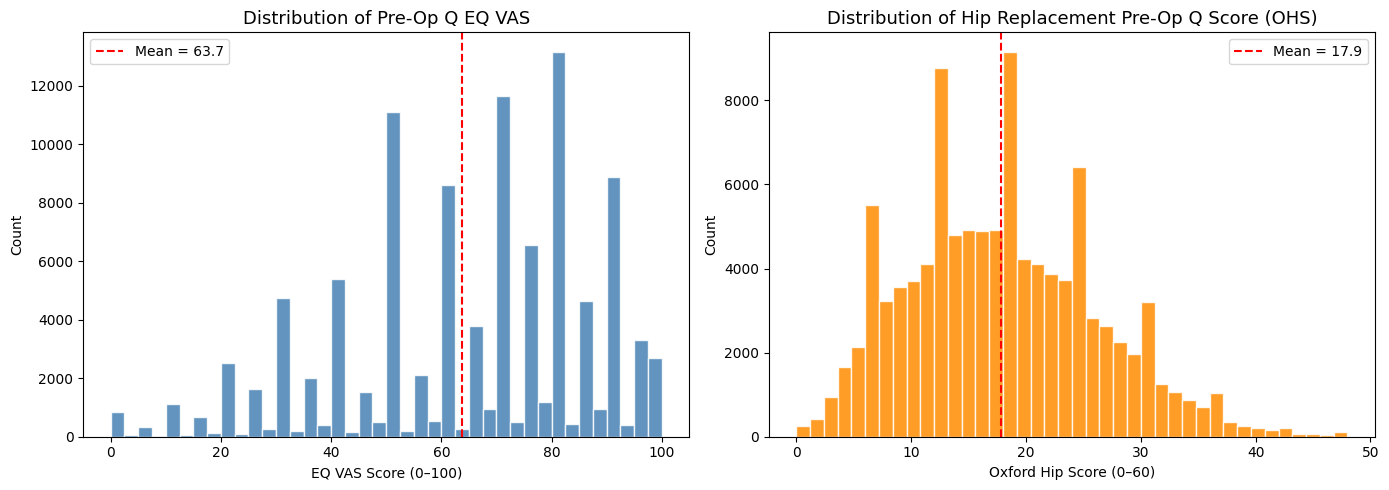

Distribution plots saved.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean[col_eq_vas].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Pre-Op Q EQ VAS', fontsize=13)
axes[0].set_xlabel('EQ VAS Score (0–100)')
axes[0].set_ylabel('Count')
axes[0].axvline(df_clean[col_eq_vas].mean(), color='red', linestyle='--', label=f'Mean = {df_clean[col_eq_vas].mean():.1f}')
axes[0].legend()

axes[1].hist(df_clean[col_ohs].dropna(), bins=40, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution of Hip Replacement Pre-Op Q Score (OHS)', fontsize=13)
axes[1].set_xlabel('Oxford Hip Score (0–60)')
axes[1].set_ylabel('Count')
axes[1].axvline(df_clean[col_ohs].mean(), color='red', linestyle='--', label=f'Mean = {df_clean[col_ohs].mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('dist_eqvas_ohs.png', dpi=150, bbox_inches='tight')
plt.show()
print('Distribution plots saved.')

## 4. Correlation Coefficients

Both **Pearson** (linear) and **Spearman** (rank-based / monotonic) correlations are calculated.
Spearman is preferred when distributions are skewed or ordinal in nature, which is common for health scores.

In [9]:
pearson_r,  pearson_p  = stats.pearsonr( df_clean[col_eq_vas], df_clean[col_ohs])
spearman_r, spearman_p = stats.spearmanr(df_clean[col_eq_vas], df_clean[col_ohs])
kendall_tau, kendall_p = stats.kendalltau(df_clean[col_eq_vas], df_clean[col_ohs])

print('=== Correlation Results ===')
print(f"Pearson  r  = {pearson_r:.4f}  (p = {pearson_p:.2e})")
print(f"Spearman ρ  = {spearman_r:.4f}  (p = {spearman_p:.2e})")
print(f"Kendall  τ  = {kendall_tau:.4f}  (p = {kendall_p:.2e})")

def interpret(r):
    r = abs(r)
    if r >= 0.7:   return 'Strong'
    elif r >= 0.4: return 'Moderate'
    elif r >= 0.2: return 'Weak'
    else:          return 'Negligible'

print(f"\nInterpretation (Pearson):  {interpret(pearson_r)} correlation")
print(f"Interpretation (Spearman): {interpret(spearman_r)} correlation")

=== Correlation Results ===
Pearson  r  = 0.3724  (p = 0.00e+00)
Spearman ρ  = 0.3499  (p = 0.00e+00)
Kendall  τ  = 0.2533  (p = 0.00e+00)

Interpretation (Pearson):  Weak correlation
Interpretation (Spearman): Weak correlation


## 5. Scatter Plot with Regression Line

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

# Hex-bin plot to handle overplotting with large N
hb = ax.hexbin(
    df_clean[col_eq_vas], df_clean[col_ohs],
    gridsize=50, cmap='Blues', mincnt=1
)
plt.colorbar(hb, ax=ax, label='Count')

# Regression line
m, b, *_ = stats.linregress(df_clean[col_eq_vas], df_clean[col_ohs])
x_line = np.linspace(df_clean[col_eq_vas].min(), df_clean[col_eq_vas].max(), 200)
ax.plot(x_line, m * x_line + b, color='red', linewidth=2,
        label=f'OLS: OHS = {m:.3f}·EQ_VAS + {b:.2f}')

ax.set_xlabel('Pre-Op Q EQ VAS (0–100)', fontsize=12)
ax.set_ylabel('Hip Replacement Pre-Op Q Score / OHS (0–60)', fontsize=12)
ax.set_title(
    f'Pre-Op Q EQ VAS vs OHS\nPearson r = {pearson_r:.3f}, Spearman ρ = {spearman_r:.3f}  (n = {len(df_clean):,})',
    fontsize=13
)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('scatter_eqvas_ohs.png', dpi=150, bbox_inches='tight')
plt.show()
print('Scatter plot saved.')

## 6. Correlation Heatmap

In [ ]:
corr_matrix = df_clean[[col_eq_vas, col_ohs]].corr(method='spearman')

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.4f',
    cmap='coolwarm', center=0,
    linewidths=0.5, square=True,
    ax=ax
)
ax.set_title('Spearman Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.savefig('heatmap_eqvas_ohs.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap saved.')

## 7. Box Plot of OHS Across Binned EQ VAS Groups

Binning EQ VAS into deciles lets us see whether higher self-reported health (EQ VAS) is consistently associated with a higher Oxford Hip Score.

In [ ]:
df_clean = df_clean.copy()
df_clean['EQ VAS Decile'] = pd.qcut(
    df_clean[col_eq_vas], q=10,
    labels=[f'D{i}' for i in range(1, 11)],
    duplicates='drop'
)

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(
    data=df_clean, x='EQ VAS Decile', y=col_ohs,
    palette='Blues', ax=ax
)
ax.set_xlabel('EQ VAS Decile (D1 = lowest, D10 = highest health state)', fontsize=11)
ax.set_ylabel('Hip Replacement Pre-Op Q Score (OHS)', fontsize=11)
ax.set_title('OHS Distribution by EQ VAS Decile', fontsize=13)
plt.tight_layout()
plt.savefig('boxplot_eqvas_deciles_ohs.png', dpi=150, bbox_inches='tight')
plt.show()
print('Box plot saved.')

## 8. Summary Statistics by EQ VAS Decile

In [ ]:
summary = (
    df_clean.groupby('EQ VAS Decile', observed=True)[col_ohs]
    .agg(['count', 'mean', 'median', 'std'])
    .round(2)
)
summary.columns = ['N', 'Mean OHS', 'Median OHS', 'Std OHS']
print(summary.to_string())

## 9. Key Findings

In [ ]:
print('=== KEY FINDINGS ===')
print(f'  Sample size (complete pairs)  : {len(df_clean):,}')
print(f'  Pearson  r                    : {pearson_r:.4f}  (p = {pearson_p:.2e})')
print(f'  Spearman ρ                    : {spearman_r:.4f}  (p = {spearman_p:.2e})')
print(f'  Kendall  τ                    : {kendall_tau:.4f}  (p = {kendall_p:.2e})')
print(f'  Regression slope (OLS)        : OHS increases by {m:.3f} per 1-unit rise in EQ VAS')
print()
print('  Interpretation:')
strength = interpret(spearman_r)
direction = 'positive' if spearman_r > 0 else 'negative'
print(f'    A {strength.lower()} {direction} monotonic association exists between')
print('    Pre-Op Q EQ VAS and Hip Replacement Pre-Op Q Score (OHS).')
print('    Patients who report a better overall health state on the EQ VAS')
print('    tend to have a higher (better) Oxford Hip Score pre-operatively.')